Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

C:\Users\sande\AppData\Local\Temp\ipykernel_8008\1120245705.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

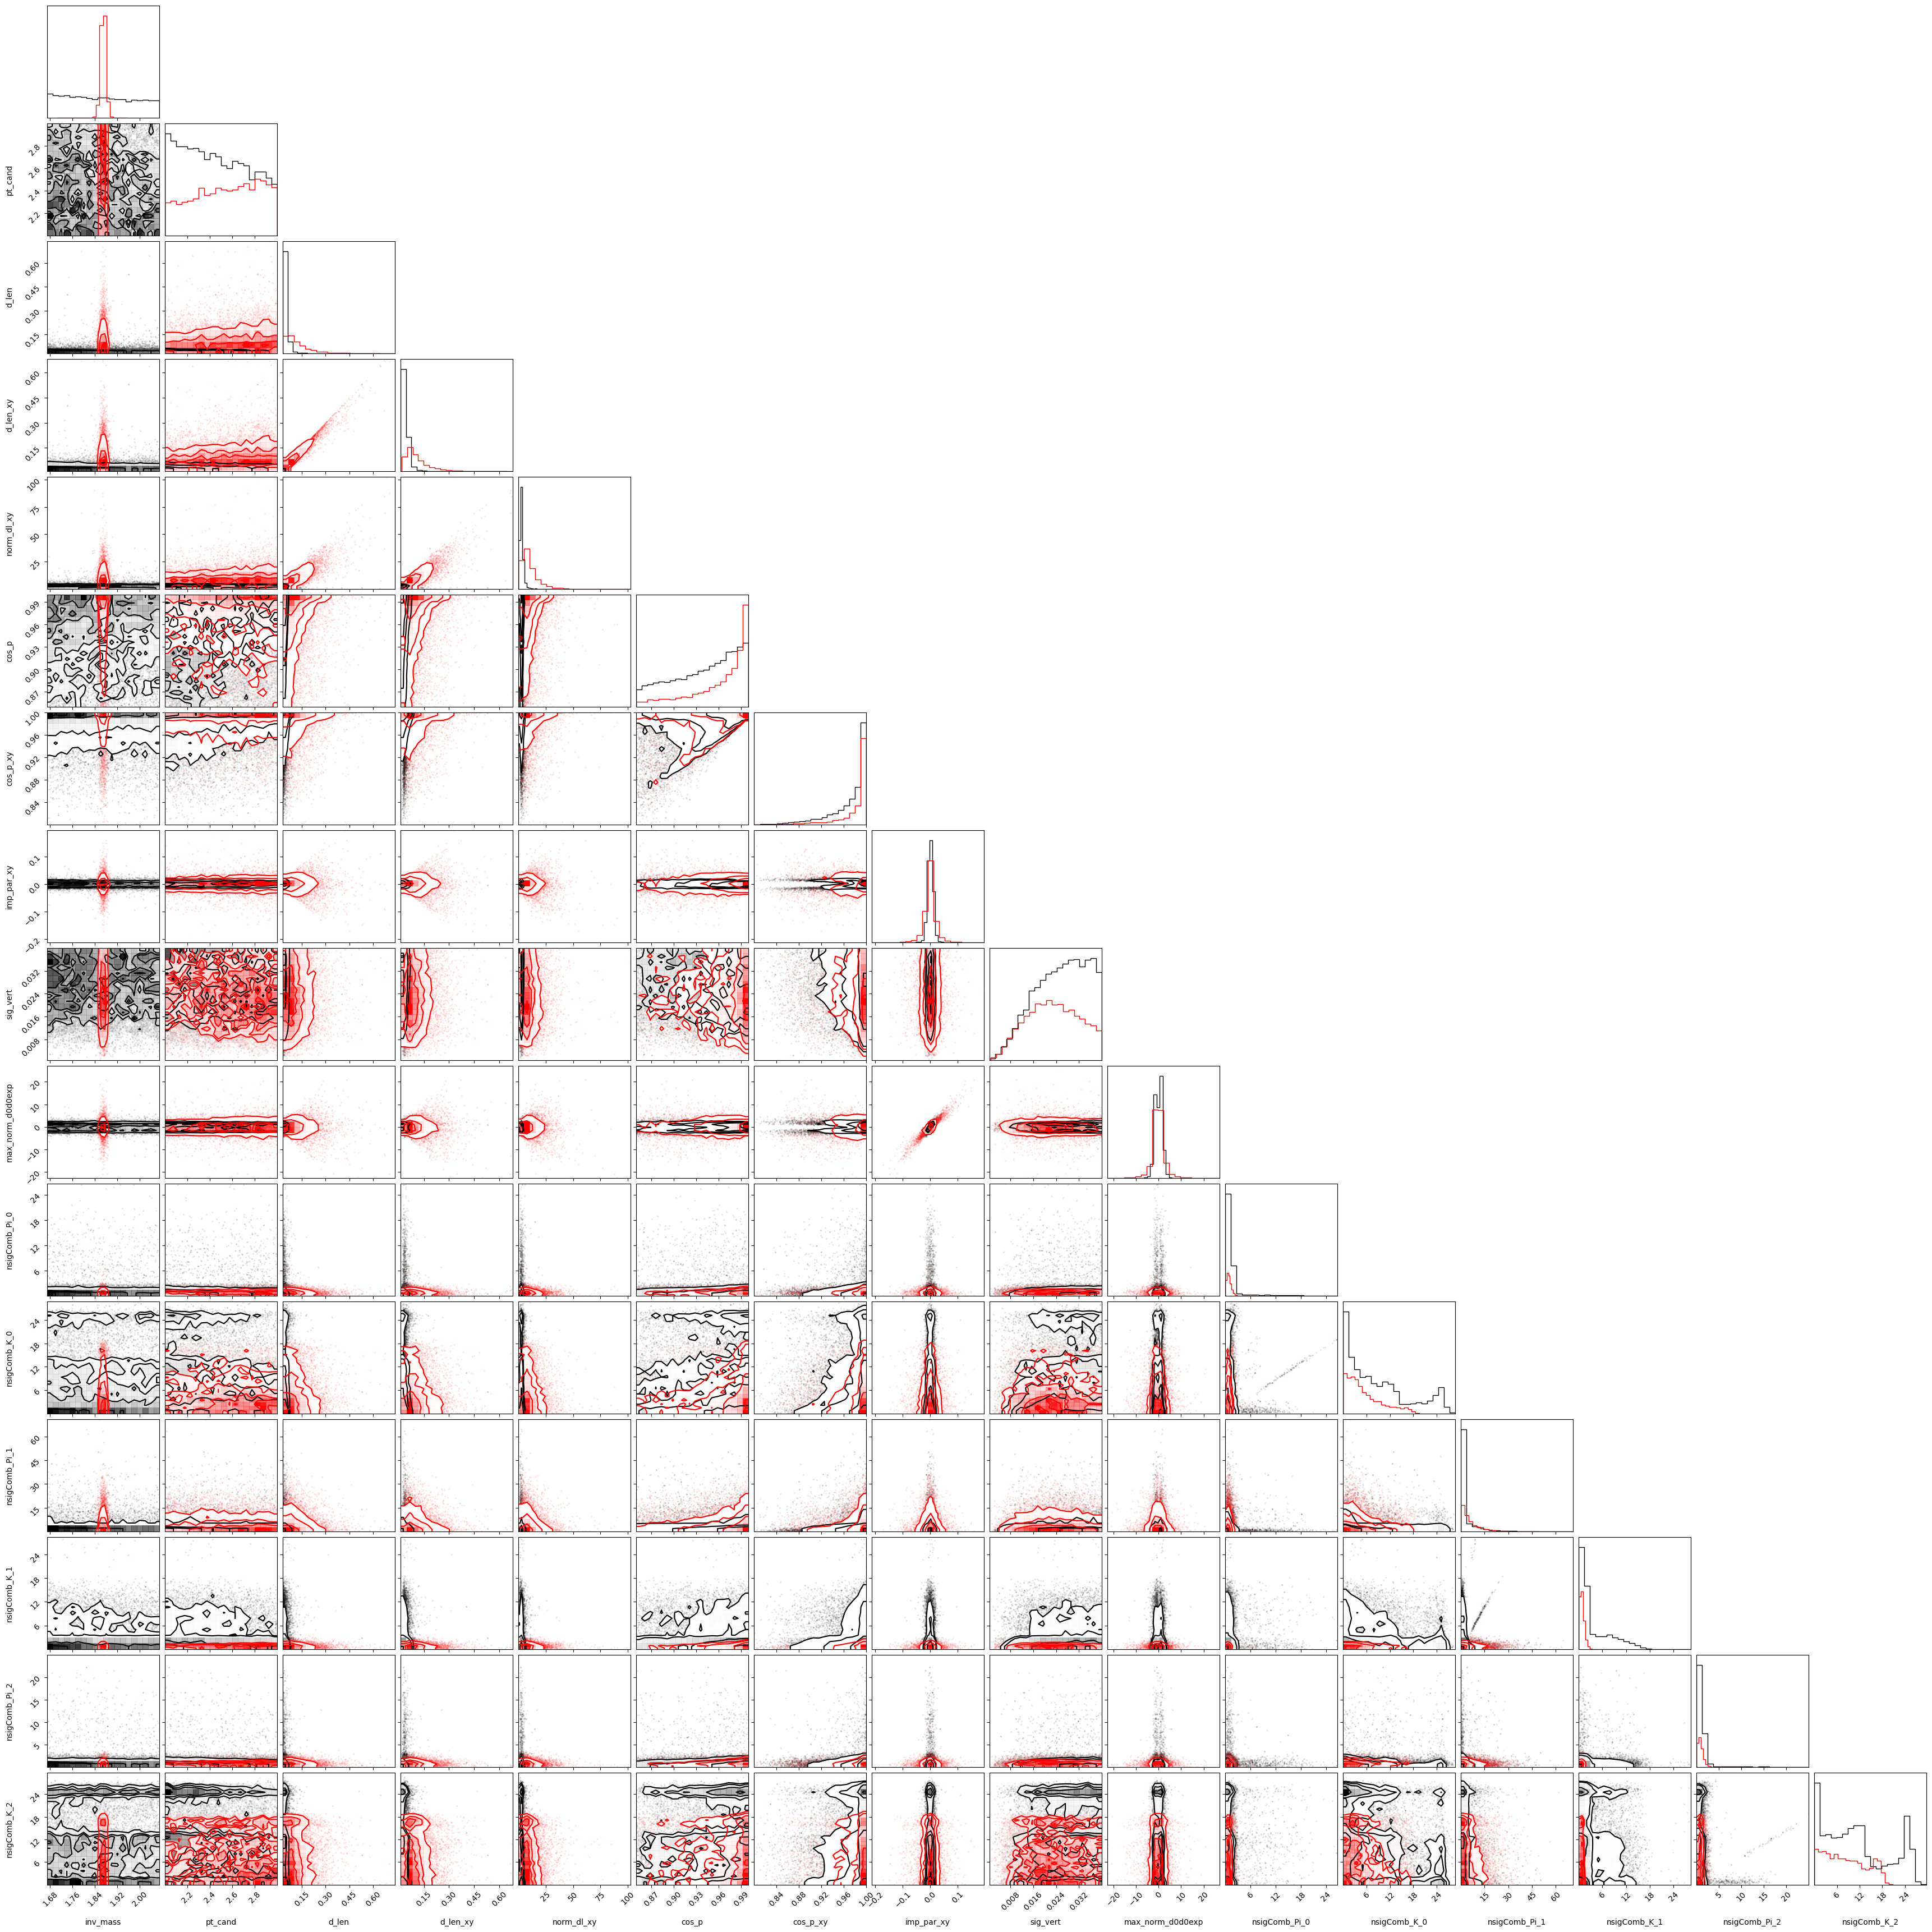

In [5]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    data_matrix = np.column_stack([training_data_bkg[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    data_matrix = np.column_stack([training_data_FD[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    corner.corner(data_matrix, labels=branches,fig=fig,color='red')
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')
    fig.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

kbg_df = pd.DataFrame(training_data_FD)
FD_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([kbg_df,FD_df])


In [ ]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score, accuracy_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

x_data = full_data[branches]
y_data = full_data['species']



x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.1, random_state=7)


evals_result = {}
# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = 12
model = xgb.XGBClassifier(
    n_estimators=1000,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42
)
model.fit(x_train, y_train, 
          eval_set=[(x_train, y_train), (x_test, y_test)],
    verbose=False
    )

In [ ]:

# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results
y_predict = model.predict(x_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predict)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
print(evaluate_results(y_test, y_predict))


In [ ]:
import optuna
# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=7)
print(np.unique(y_train, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = len(training_data_FD['inv_mass'])/len(training_data_bkg['inv_mass'])*10000
print(pos_class_weight)
model = xgb.XGBClassifier(
    n_estimators=100,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42
)
model.fit(x_train, y_train)


def objective(trial):
    data, target =  full_data[branches], full_data['species']
    train_x, test_x, train_y, test_y = train_test_split(data, target, test_size=0.25)
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x, label=test_y)

    param = {
        "silent": 1,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0,log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0,log=True),
    }

    if param["booster"] == "gbtree" or param["booster"] == "dart":
        param["max_depth"] = trial.suggest_int("max_depth", 1, 9)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0,log=True)
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0,log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0,log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0,log=True)

    # Add a callback for pruning.
    # We are sampling the hyperparameterspace for what combination of hyperparameters results in a fast learning algorithm
    # For samples that learn very slowly, we do not need to train them for many epochs
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-auc")
    bst = xgb.train(param, dtrain, evals=[(dtest, "validation")], callbacks=[pruning_callback])
    preds = bst.predict(dtest)
    pred_labels = np.rint(preds)
    accuracy = sklearn.metrics.f1_score(test_y, pred_labels) # F1 score voor ongebalanceerde data
    # Let op met welke metric we gebruiken als accuracy hier. Omdat de dataset heel ongebalanceerd is, 
    # moedigen we hier modellen aan die alles klassificeren als geen D+ deeltje, omdat dat al best goed in de buurt van het juiste antwoord is
    # We hebben immers veel minder D+ deeltjes
    return accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=30)
print(study.best_trial)

In [ ]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

In [ ]:
import optuna
import optuna_integration
from plotly.io import show
# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)
fig = optuna.visualization.plot_timeline(study)
show(fig)

In [ ]:

#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/
best_params = study.best_params
print(best_params)
model = xgb.XGBClassifier(**best_params
)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(classification_report(y_test, pred))
evaluate_results(y_test, pred)